In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
X, y = make_classification(n_samples=3000, n_features=20, n_informative=15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train, X_val = scaler.fit_transform(X_train), scaler.transform(X_val)

In [3]:
def to_loader(X, y, batch_size=64):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

In [4]:
train_loader = to_loader(X_train, y_train)
val_loader   = to_loader(X_val, y_val)

In [5]:
def make_model(activation=nn.ReLU(), dropout=0.0):
    layers = [nn.Linear(20, 128), activation, nn.Dropout(dropout),
              nn.Linear(128, 64), activation, nn.Dropout(dropout),
              nn.Linear(64, 1), nn.Sigmoid()]
    return nn.Sequential(*layers)

In [8]:
def run(model, optimizer, epochs=40):
    criterion = nn.BCELoss()
    h = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            loss = criterion(model(xb), yb.unsqueeze(1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        for phase, loader in [('train', train_loader), ('val', val_loader)]:
            model.eval()
            losses, correct, total = [], 0, 0
            with torch.no_grad():
                for xb, yb in loader:
                    out = model(xb)
                    losses.append(criterion(out, yb.unsqueeze(1)).item())
                    correct += ((out > 0.5).squeeze() == yb.bool()).sum().item()
                    total += len(yb)
            h[f'{phase}_loss'].append(sum(losses)/len(losses))
            h[f'{phase}_acc'].append(100 * correct / total)
    return h


Sigmoid: val_acc=88.8%
Tanh: val_acc=96.8%
ReLU: val_acc=96.7%
LeakyReLU: val_acc=97.1%
SGD: val_acc=96.5%
Adam: val_acc=97.2%
dropout=0.0: train=100.0% val=90.9% gap=9.1pp
dropout=0.3: train=100.0% val=90.5% gap=9.5pp
dropout=0.5: train=97.3% val=89.2% gap=8.1pp


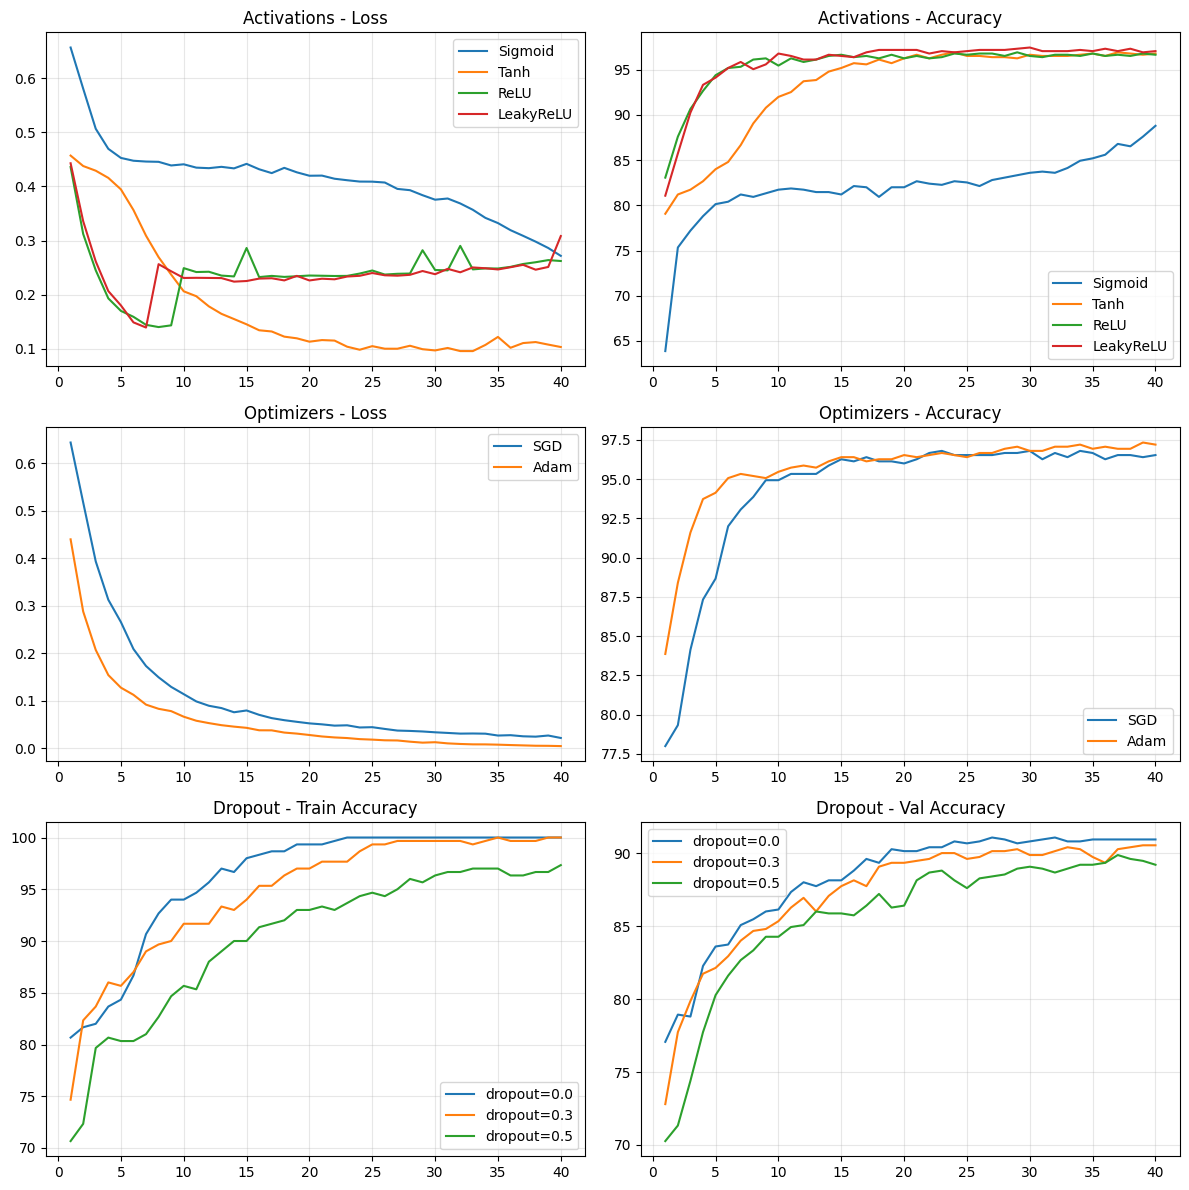

In [14]:
ep = range(1, 41)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))


# Activation functions
activations = {'Sigmoid': nn.Sigmoid(), 'Tanh': nn.Tanh(), 'ReLU': nn.ReLU(), 'LeakyReLU': nn.LeakyReLU(0.1)}
act_results = {}
for name, act in activations.items():
    model = make_model(activation=act)
    h = run(model, optim.Adam(model.parameters(), lr=1e-3))
    act_results[name] = h
    print(f"{name}: val_acc={h['val_acc'][-1]:.1f}%")

for metric, ax in zip(['val_loss', 'val_acc'], axes[0]):
    for name, h in act_results.items():
        ax.plot(ep, h[metric], label=name)
    ax.set_title(f"Activations - {'Loss' if 'loss' in metric else 'Accuracy'}")
    ax.legend(); ax.grid(alpha=0.3)

# SGD vs Adam
opt_results = {}
for name, opt_fn in [('SGD', lambda p: optim.SGD(p, lr=0.01, momentum=0.9)),
                     ('Adam', lambda p: optim.Adam(p, lr=1e-3))]:
    model = make_model()
    h = run(model, opt_fn(model.parameters()))
    opt_results[name] = h
    print(f"{name}: val_acc={h['val_acc'][-1]:.1f}%")

for metric, ax in zip(['train_loss', 'val_acc'], axes[1]):
    for name, h in opt_results.items():
        ax.plot(ep, h[metric], label=name)
    ax.set_title(f"Optimizers - {'Loss' if 'loss' in metric else 'Accuracy'}")
    ax.legend(); ax.grid(alpha=0.3)

X_small = torch.FloatTensor(X_train[:300]); y_small = torch.FloatTensor(y_train[:300])
small_loader = DataLoader(TensorDataset(X_small, y_small), batch_size=32, shuffle=True)

orig_train_loader = train_loader
train_loader = small_loader

drop_results = {}
for rate in [0.0, 0.3, 0.5]:
    model = make_model(dropout=rate)
    h = run(model, optim.Adam(model.parameters(), lr=1e-3))
    drop_results[rate] = h
    gap = h['train_acc'][-1] - h['val_acc'][-1]
    print(f"dropout={rate}: train={h['train_acc'][-1]:.1f}% val={h['val_acc'][-1]:.1f}% gap={gap:.1f}pp")

train_loader = orig_train_loader

for metric, ax in zip(['train_acc', 'val_acc'], axes[2]):
    for rate, h in drop_results.items():
        ax.plot(ep, h[metric], label=f'dropout={rate}')
    ax.set_title(f"Dropout - {'Train' if 'train' in metric else 'Val'} Accuracy")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task6_plots.png", dpi=150)
plt.show()